In [38]:
import numpy as np
import pandas as pd
from typing import List, Dict
import seaborn as sns
import matplotlib.pyplot as plt

***Data Preprocessing***

In [39]:
df = pd.read_csv("data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

#separate into data and targets
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_vld, y_train, y_vld = train_test_split(X_train, y_train, train_size=0.8, random_state=42)

#standardize nonbinary features
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
nonbinary_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

ct = ColumnTransformer(
    [('binary', 'passthrough', binary_features),
     ('non_binary', StandardScaler(), nonbinary_features)]
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)
X_vld = ct.transform(X_vld)

print(pd.DataFrame(X_train).describe())

                 0             1             2             3             4   \
count  45242.000000  45242.000000  45242.000000  45242.000000  45242.000000   
mean       0.563304      0.525905      0.975023      0.475487      0.061934   
std        0.495982      0.499334      0.156056      0.499404      0.241038   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      1.000000      0.000000      0.000000   
50%        1.000000      1.000000      1.000000      0.000000      0.000000   
75%        1.000000      1.000000      1.000000      1.000000      0.000000   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

                 5             6             7             8             9   \
count  45242.000000  45242.000000  45242.000000  45242.000000  45242.000000   
mean       0.146744      0.704876      0.614274      0.789930      0.043676   
std        0.353855      0.456104      0.486772    

In [41]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
def plot_confusion_matrix(y: np.ndarray, y_hat: np.ndarray, class_names: Dict[int, str] = {0: "No Diabetes", 1: "Diabetes or Pre-Diabetes"}) -> pd.DataFrame:
    y = y.flatten()
    y_hat = y_hat.flatten()

    cfm = confusion_matrix(y, y_hat)

    labels = np.sort(np.unique(y))
    if class_names is not None:
        classes = []
        for l in labels:
            class_name = class_names.get(l, l)
            classes.append(class_name)
        labels = classes
        
    columns, index = labels, labels
    cfm_df = pd.DataFrame(cfm, index=index, columns=columns)
    sns.heatmap(cfm_df, annot=True, fmt=".0f")

    return cfm_df

def display_statistics(y: np.ndarray, y_hat: np.ndarray):
    acc = accuracy_score(y, y_hat)
    precision = precision_score(y, y_hat)
    recall = recall_score(y, y_hat)
    f1 = f1_score(y, y_hat)


    print(f"F1 Score: {f1}\nPrecision: {precision}\nRecall: {recall}\nAccuracy: {acc}")

    plot_confusion_matrix(y, y_hat)

F1 Scores:
1 Neighbors: 0.6656810982048574
10 Neighbors: 0.7231340088482946
25 Neighbors: 0.7541846652267818
50 Neighbors: 0.7558052941574708
100 Neighbors: 0.7591426657736102
200 Neighbors: 0.7594513215122114
1000 Neighbors: 0.7560698281051434
2000 Neighbors: 0.7553198630596765


---- Optimal: K = 100 ----
F1 Score: 0.7591426657736102
Precision: 0.7190711838599163
Recall: 0.8039438218186977
Accuracy: 0.7456680104675012


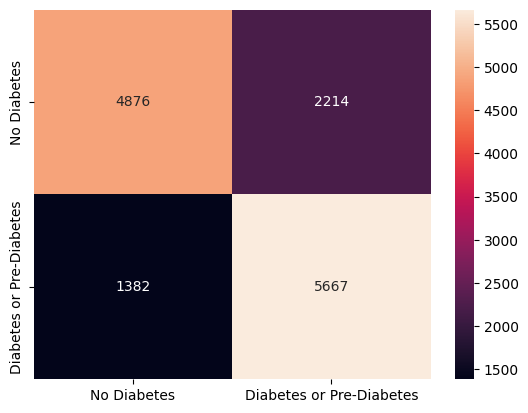

In [42]:
from sklearn.neighbors import KNeighborsClassifier

ks = [1, 10, 25, 50, 100, 200, 1000, 2000]

print("F1 Scores:")
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_hat = knn.predict(X_test)
    
    print(f"{k} Neighbors: {f1_score(np.array(y_test), y_hat)}")

print("\n\n---- Optimal: K = 100 ----")
knn = KNeighborsClassifier(n_neighbors=100)
knn.fit(X_train, y_train)

y_hat = knn.predict(X_test)
display_statistics(np.array(y_test), y_hat)

F1 Score: 0.7495786516853933
Precision: 0.7421777221526908
Recall: 0.7571286707334374
Accuracy: 0.7477898012589292


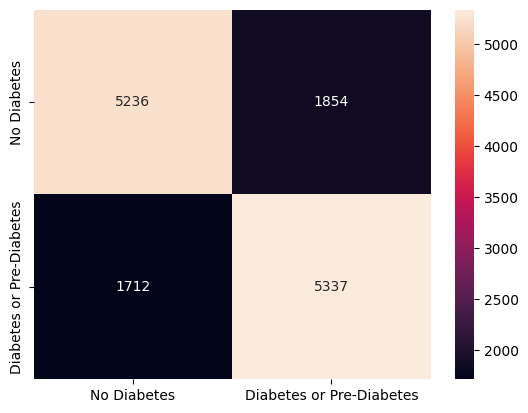

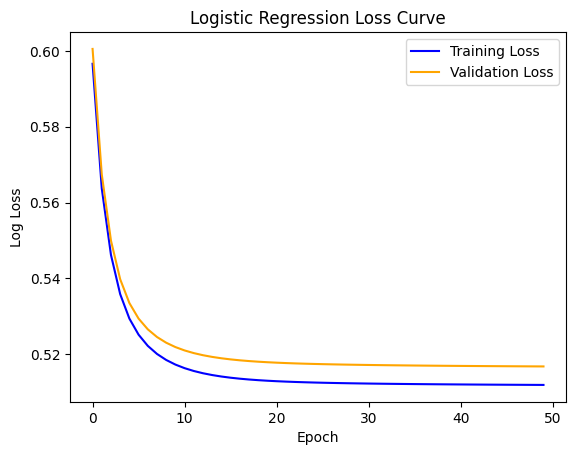

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

lr = SGDClassifier(loss="log_loss", max_iter=1, warm_start=True, alpha=0.0001, random_state=42)
epochs = 50
train_losses = []
vld_losses = []

# initialize with partial_fit
lr.partial_fit(X_train, y_train, classes=np.unique(y_train))

for i in range(epochs):
    lr.partial_fit(X_train, y_train)

    y_train_proba = lr.predict_proba(X_train)
    train_losses.append(log_loss(y_train, y_train_proba))

    y_vld_proba = lr.predict_proba(X_vld)
    vld_losses.append(log_loss(y_vld, y_vld_proba))



y_hat = lr.predict(X_test)
display_statistics(np.array(y_test), y_hat)
plt.show()

plt.plot(np.arange(epochs), train_losses, label="Training Loss", color="blue")
plt.plot(np.arange(epochs), vld_losses, label="Validation Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Logistic Regression Loss Curve")
plt.legend()
plt.show()
